# DES Shear Tomo 4x4 Fig. 4 Check

Quick DES-only NaMaster check for the source-bin 4x4 shear EE spectrum. This runs the paper-like setup used for Fig. 4 of `2203.07128v1.pdf`: `nside=1024`, 32 square-root-spaced equal-weight bandpowers over `ell=8..2048`, the raw Metacalibration-weight mask, and HEALPix polarization pixel-window deconvolution in the measurement weights. The plotted quantity is `Lbar * C_L^EE` in units of `1e-7`, matching the paper caption.

In [1]:
from pathlib import Path
import json
import sys

import numpy as np

def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()
    for path in (start, *start.parents):
        if (path / 'data/xDESI/survey_data/manifest.json').exists():
            return path
    raise RuntimeError('Could not find GODMAX repo root from current working directory.')

REPO = find_repo_root()
SURVEY_MEASURE = REPO / 'notebooks/xDESI/survey_measure'
if str(SURVEY_MEASURE) not in sys.path:
    sys.path.insert(0, str(SURVEY_MEASURE))

from diagnose_des_shear_harmonic import (
    SCENARIOS,
    MeasurementConfig,
    SurveyBundle,
    plot_shear_pair_result,
    run_shear_pair_scenario,
    write_shear_pair_result,
)

SURVEY_ROOT = REPO / 'data/xDESI/survey_data'
OUTPUT_JSON = REPO / 'data/xDESI/processed/multiprobe_namaster/diagnostics/des_shear_tomo4x4_fig4_check.json'
OUTPUT_PNG = REPO / 'data/xDESI/processed/multiprobe_namaster/diagnostics/des_shear_tomo4x4_fig4_check.png'
PAPER_PDF = REPO / 'notebooks/xDESI/papers/shear_harmonic/2203.07128v1.pdf'

print(REPO)
print(PAPER_PDF)

/mnt/ceph/users/spandey/ltu-godmax/GODMAX
/mnt/ceph/users/spandey/ltu-godmax/GODMAX/notebooks/xDESI/papers/shear_harmonic/2203.07128v1.pdf


In [2]:
SCENARIO_NAME = 'paper_like_raw_mask_pixwin_ell8_2048'
scenario = next(s for s in SCENARIOS if s.name == SCENARIO_NAME)

bundle = SurveyBundle.from_root(SURVEY_ROOT)
bundle.validate_files()
base_config = MeasurementConfig.for_stage('lowres')

result = run_shear_pair_scenario(
    bundle,
    base_config=base_config,
    scenario=scenario,
    tomo_i=4,
    tomo_j=4,
    compute_covariance=True,
)
write_shear_pair_result(result, OUTPUT_JSON)

print(f"saved: {OUTPUT_JSON}")
print(f"scenario: {result['scenario']}")
print(f"diag S/N: {result['diag_snr']:.3f}")
print(f"first/last ell edges: {result['ell_left'][0]}..{result['ell_right'][-1] - 1}")

saved: /mnt/ceph/users/spandey/ltu-godmax/GODMAX/data/xDESI/processed/multiprobe_namaster/diagnostics/des_shear_tomo4x4_fig4_check.json
scenario: paper_like_raw_mask_pixwin_ell8_2048
diag S/N: 7.015
first/last ell edges: 8..2048


In [3]:
ell = np.asarray(result['ell'])
y = np.asarray(result['ell_cl_1e7'])
yerr = np.asarray(result['ell_err_1e7'])

print('Fig. 4-style plotted quantity: Lbar*C_L^EE [1e-7]')
print(f'min / median / max: {np.nanmin(y):.3f} / {np.nanmedian(y):.3f} / {np.nanmax(y):.3f}')
print(f'negative EE bands: {np.count_nonzero(y < 0)} / {y.size}')
print('first eight bands:')
for k in range(8):
    print(f"  ell={ell[k]:7.1f}: {y[k]:7.3f} +/- {yerr[k]:7.3f}")

Fig. 4-style plotted quantity: Lbar*C_L^EE [1e-7]
min / median / max: 1.497 / 3.623 / 6.866
negative EE bands: 0 / 32
first eight bands:
  ell=   12.0:   1.497 +/-   0.962
  ell=   23.0:   6.056 +/-   1.576
  ell=   37.5:   6.866 +/-   2.569
  ell=   55.5:   5.958 +/-   3.325
  ell=   77.0:   5.302 +/-   4.708
  ell=  102.0:   6.026 +/-   2.987
  ell=  131.0:   5.142 +/-   3.836
  ell=  163.0:   3.846 +/-   3.316


saved: /mnt/ceph/users/spandey/ltu-godmax/GODMAX/data/xDESI/processed/multiprobe_namaster/diagnostics/des_shear_tomo4x4_fig4_check.png


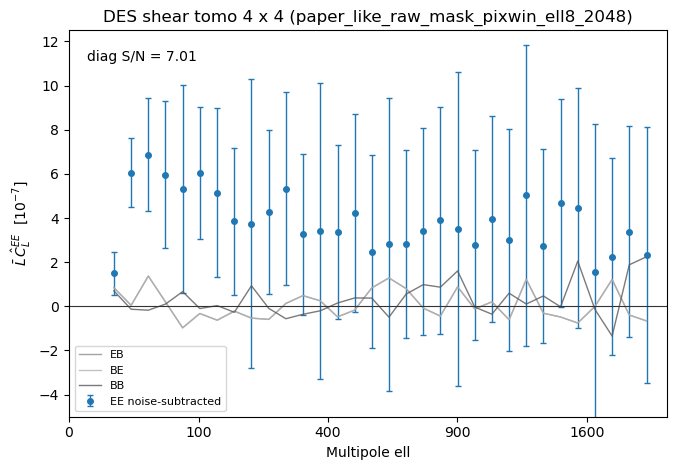

In [4]:
fig, ax = plot_shear_pair_result(result, OUTPUT_PNG)
ax.set_ylim(-5.0, 12.5)
print(f'saved: {OUTPUT_PNG}')

In [5]:
# Optional: compare against the multi-probe-like convention, without raw-mask/pixel-window corrections.
RUN_MULTIPROBE_LIKE = False

if RUN_MULTIPROBE_LIKE:
    alt = next(s for s in SCENARIOS if s.name == 'paper_range_norm_mask_no_pixwin_ell8_2048')
    alt_result = run_shear_pair_scenario(bundle, base_config, alt, tomo_i=4, tomo_j=4, compute_covariance=True)
    print(f"paper-like diag S/N: {result['diag_snr']:.3f}")
    print(f"multi-probe-like diag S/N: {alt_result['diag_snr']:.3f}")
    print('median L*C_L [1e-7]:', np.nanmedian(result['ell_cl_1e7']), np.nanmedian(alt_result['ell_cl_1e7']))